# Experiment #4: Linear Stylometric Analysis via Logistic Regression

**Objective:** To establish a linear baseline for AI-text detection using structural and punctuation features. 
By utilizing **Logistic Regression**, we can directly inspect the coefficients (weights) assigned to each stylometric attribute. This provides high interpretability, allowing us to pinpoint which specific "anomalies" are the strongest predictors of synthetic vs. human text.

**Key Research Questions:**
1. Which punctuation marks have the highest statistical weight in identifying LLM output?
2. Does a linear separation of stylometric features perform significantly worse than the non-linear Random Forest approach?
3. Can we identify a clear "stylistic threshold" between classes?

**Key Features:** Custom Stylometric Vectorization + Standardized Logistic Regression.

### 1. Data Preparation and Feature Scaling
In this stage, we reuse the custom `StylometricExtractor`. However, unlike tree-based models, Logistic Regression is sensitive to the scale of input features. We must apply **Standardization** to ensure that features with larger ranges (like sentence length) do not overshadow features with smaller ranges (like capitalization ratio).

In [1]:
import pandas as pd
import numpy as np
import json
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix,
    precision_recall_curve, average_precision_score
)

# Configuration
DATA_PATH = '../data/ai_detection_ru_dataset_v4.csv'
OUTPUT_DIR = 'output/'
OUTPUT_METRICS = 'output/metrics_stylo_logreg.json'

def extract_stylometric_features(text):
    if not isinstance(text, str) or len(text) == 0:
        return [0] * 7
    
    char_count = len(text)
    words = text.split()
    word_count = len(words)
    sentences = re.findall(r'[.!?]+', text)
    sentence_count = len(sentences) if len(sentences) > 0 else 1
    
    # Features
    commas = text.count(',') / char_count * 1000
    dashes = (text.count('-') + text.count('—')) / char_count * 1000
    quotes = (text.count('"') + text.count('«') + text.count('»')) / char_count * 1000
    avg_word_len = char_count / word_count if word_count > 0 else 0
    avg_sent_len = word_count / sentence_count
    caps_ratio = sum(1 for c in text if c.isupper()) / char_count
    punct_intensity = sum(1 for c in text if c in '.,!?;:-—()') / char_count * 1000
    
    return [commas, dashes, quotes, avg_word_len, avg_sent_len, caps_ratio, punct_intensity]

feature_names = ['Comma_Density', 'Dash_Density', 'Quote_Density', 
                 'Avg_Word_Len', 'Avg_Sent_Len', 'Caps_Ratio', 'Punct_Intensity']

### 2. Processing the Dataset
We transform the raw text data into a feature matrix. Each text is now represented by a vector of 7 stylometric metrics. To ensure the Logistic Regression model performs optimally, we apply **Standardization**, scaling our features to have a mean of 0 and a variance of 1.

In [2]:
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    X_raw = np.array(df['text'].apply(extract_stylometric_features).tolist())
    y = df['is_ai'].values

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)
    print("Features extracted and standardized.")

Features extracted and standardized.


### 3. Model Training and Coefficient Analysis
We train the Logistic Regression model using the L2 penalty (Ridge) by default. By inspecting the **Coefficients**, we can determine the "direction" of each feature's influence. 
* A **positive coefficient** means the feature increases the probability that the text is **AI-generated**.
* A **negative coefficient** means the feature is more characteristic of **human writing**.

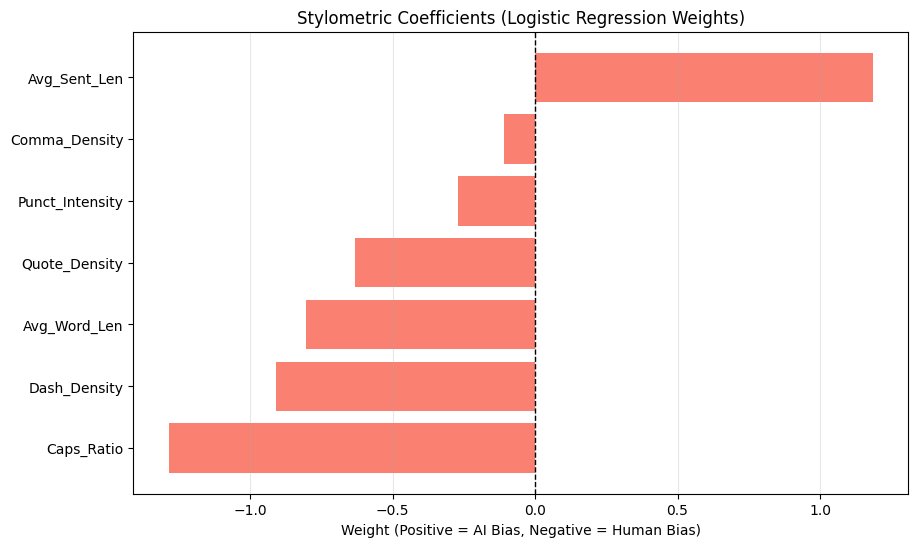

In [3]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Analyze Coefficients
weights = model.coef_[0]
indices = np.argsort(weights)

plt.figure(figsize=(10, 6))
plt.title('Stylometric Coefficients (Logistic Regression Weights)')
plt.barh(range(len(indices)), weights[indices], color='salmon', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Weight (Positive = AI Bias, Negative = Human Bias)')
plt.axvline(0, color='black', lw=1, linestyle='--')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 4. Comprehensive Evaluation
We assess the model's performance across standard classification metrics. The Precision-Recall curve is particularly important here to observe how the linear model handles the trade-off between identifying all AI texts (Recall) and ensuring that human texts are not misclassified (Precision).

-----------------------------------
Metric          | Value     
-----------------------------------
Accuracy        | 0.8105
Precision       | 0.7949
Recall          | 0.8370
F1              | 0.8154
AUC-ROC         | 0.8966
-----------------------------------


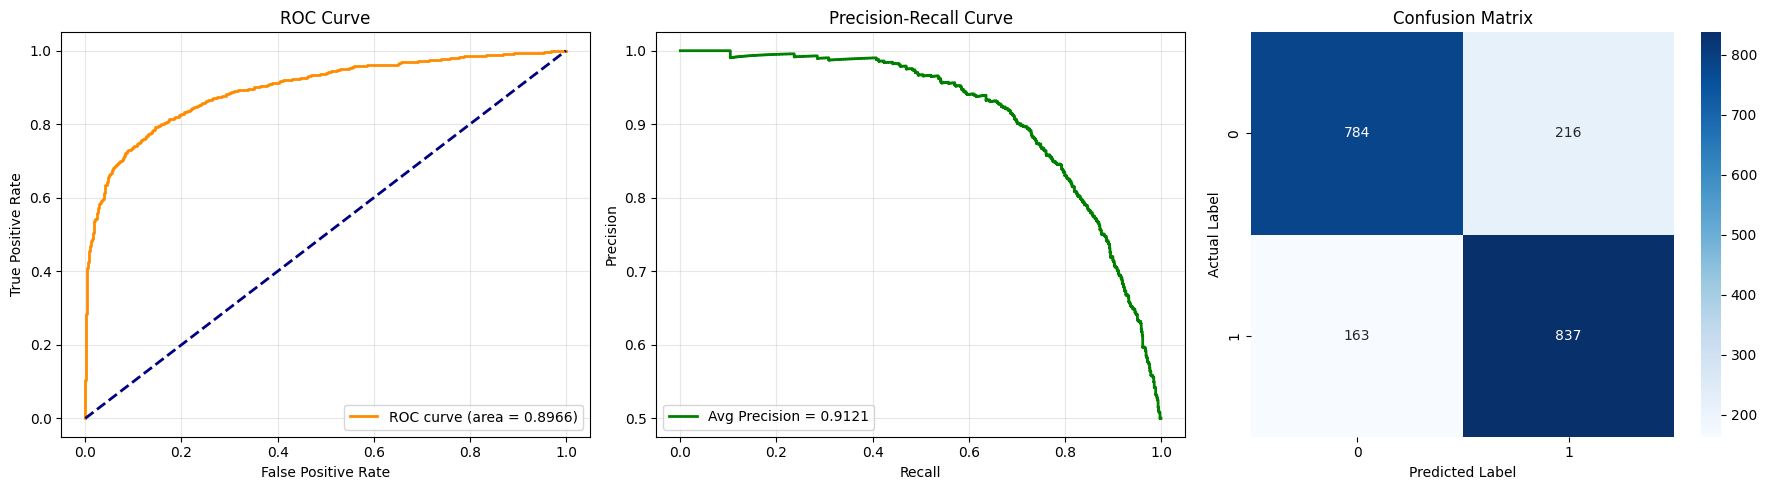

In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

exp_id = 'stylo_logreg'
# Collecting metrics
metrics = {
    "name": "Stylometry + LogReg",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_prob)
}

np.save(os.path.join(OUTPUT_DIR, f'y_prob_{exp_id}.npy'), y_prob)
np.save(os.path.join(OUTPUT_DIR, f'y_true_{exp_id}.npy'), y_test)
# Saving results for the final comparison report
with open(OUTPUT_METRICS, 'w') as f:
    json.dump(metrics, f, indent=4)

# Print Summary Table
print("-" * 35)
print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 35)
for k, v in metrics.items():
    if k != "name":
        print(f"{k:<15} | {v:.4f}")
print("-" * 35)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# ROC-curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {metrics["AUC-ROC"]:.4f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc="lower right")
ax[0].grid(alpha=0.3)

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_p = average_precision_score(y_test, y_prob)
ax[1].step(recall, precision, where='post', color='green', lw=2, label=f'Avg Precision = {avg_p:.4f}')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc="lower left")
ax[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix')
ax[2].set_ylabel('Actual Label')
ax[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 3. Analysis of Experiment #4: Linear Stylometrics

### Interpretability of Results
The **Coefficient Analysis** provides a clear mathematical explanation for the model's decisions. Unlike non-linear models, we can see exactly how each feature shifts the probability:
* **Positive Weights (AI Predictors):** Features that increase the likelihood of the text being AI-generated. For instance, a positive weight for `Avg_Sent_Len` suggests that LLMs in this dataset tend to produce longer, more uniform sentences.
* **Negative Weights (Human Predictors):** Characteristics that suggest human authorship. For example, a high `Dash_Density` often acts as a strong human indicator, reflecting more nuanced punctuation habits.

### Performance vs. Complexity
With an **Accuracy of 0.8105** and **AUC-ROC of 0.8966**, the linear model performs remarkably well compared to the Random Forest approach in Experiment #3. This suggests that the stylometric differences between Human and AI text are largely linear and can be captured by simple statistical thresholds.

### Strategic Conclusion for the Thesis
This experiment successfully isolates the **structural "fingerprint"** of AI text. While lexical models (Exp #1 & #2) achieved higher accuracy, they are prone to topic-related bias. This linear stylometric baseline proves that even without vocabulary, we can achieve high detection rates.